#Prashna Prajapati

#Worksheet_7

#Step 1: Load, pre - process and add a Noise to the Dataset:

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


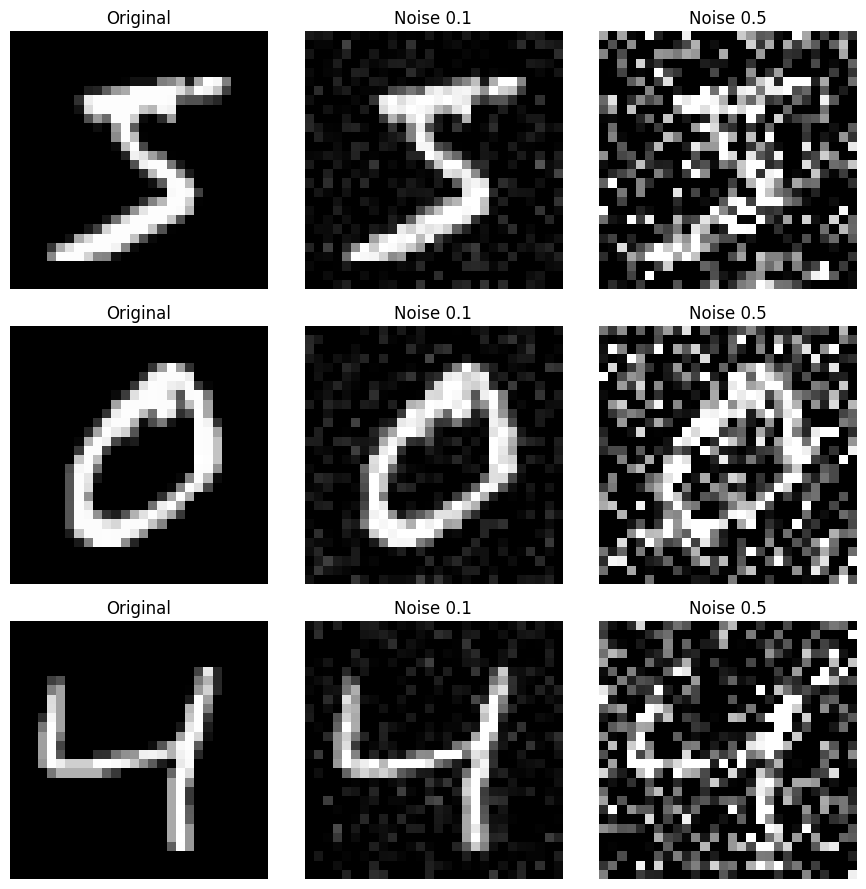

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# 1. Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# 2. Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# 3. Reshape to (28, 28, 1)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# 4. Add Gaussian noise
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape)

x_train_noisy_high = x_train + noise_factor_high * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape)

x_test_noisy_low = x_test + noise_factor_low * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape)

x_test_noisy_high = x_test + noise_factor_high * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape)

# 5. Clip values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

# 6. Visualize images
n = 3  # number of images
plt.figure(figsize=(9, 9))

for i in range(n):
    # Original
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Low Noise
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    # High Noise
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

#Step 2: Build the Convolutional Denoising Autoencoder Model:
##Building Encoder.

In [ ]:
def build_encoder(input_shape=(28, 28, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.
    """
    input_img = Input(shape=input_shape, name="input")

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)

    return input_img, encoded

##Building Decoder.

In [ ]:
def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.
    """
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)

    return decoded

##Building Autoencdoder.

In [ ]:
def build_autoencoder():
    """
    Constructs and compiles the full autoencoder.
    """
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)

    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")

    autoencoder.compile(
        optimizer=Adam(),
        loss='binary_crossentropy'
    )

    return autoencoder

##Compile the Model.

In [ ]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

#Step 3: Train the Autoencoder:

In [ ]:

# Build the autoencoder
autoencoder = build_autoencoder()

# Train using noisy input → clean target
history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.1562 - val_loss: 0.1136
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1092 - val_loss: 0.1046
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1044 - val_loss: 0.1019
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1019 - val_loss: 0.1003
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1001 - val_loss: 0.0986
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0990 - val_loss: 0.0978
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0981 - val_loss: 0.0977
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0974 - val_loss: 0.0965
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0968 - val_loss: 0.0958
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0963 - val_loss: 0.0954


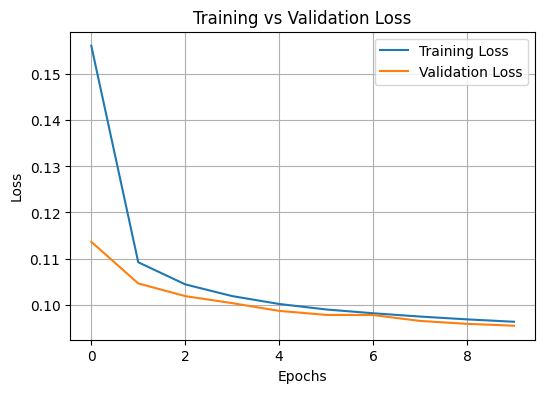

In [ ]:
# Plot loss curves
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [ ]:
denoised_images = autoencoder.predict(x_test_noisy_high)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


#Step4:Evaluate the Autoencoder:

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


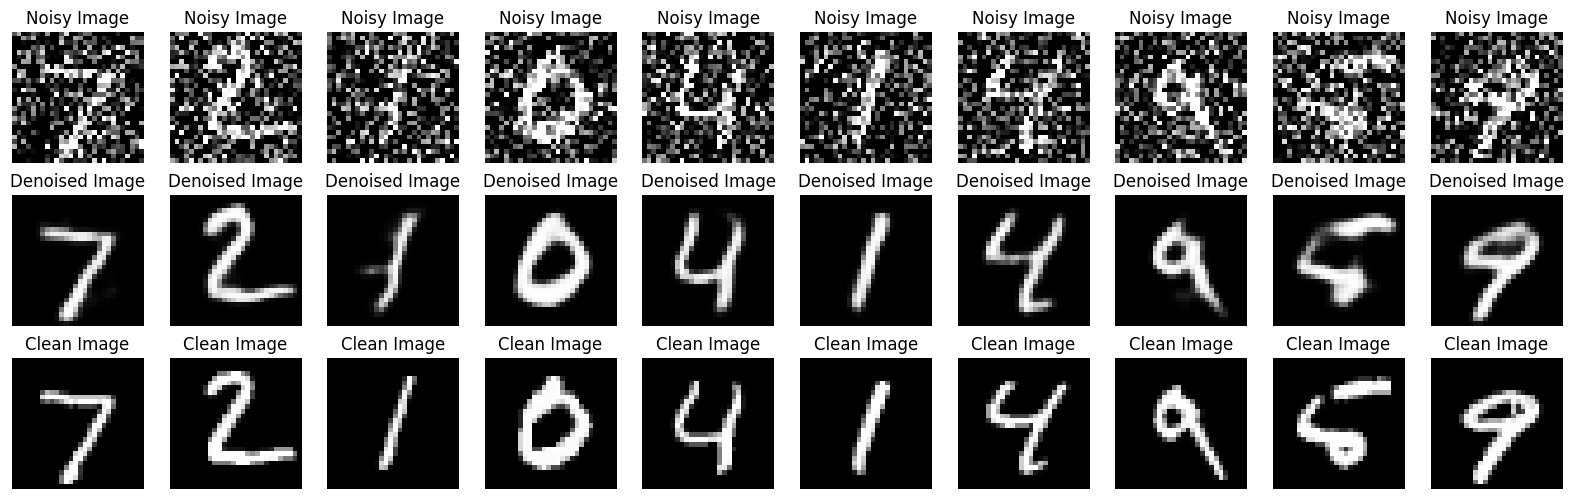

In [ ]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)

# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Plot noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')

        # Plot denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')

        # Plot clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')
    plt.show()

# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

#4 Exercise: Build a Denoising Convolutional Autoencoder

##Dataset: Devnagari Handwritten Digit Dataset:

##Step 1: Load & Preprocess Devnagari Dataset (using PIL)


In [ ]:
import os
import numpy as np
from PIL import Image

data_path = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset"

images = []

for folder_type in os.listdir(data_path):
    type_path = os.path.join(data_path, folder_type)

    if os.path.isdir(type_path):
        for digit_folder in os.listdir(type_path):
            digit_path = os.path.join(type_path, digit_folder)

            if os.path.isdir(digit_path):
                for file_name in os.listdir(digit_path):
                    img_path = os.path.join(digit_path, file_name)

                    if os.path.isfile(img_path):
                        try:
                            img = Image.open(img_path).convert('L')
                            img = img.resize((28, 28))

                            images.append(np.array(img, dtype=np.float32))
                        except:
                            continue

images = np.array(images, dtype=np.float32) / 255.0
images = images.reshape(-1, 28, 28, 1)

print("Dataset shape:", images.shape)

Dataset shape: (20000, 28, 28, 1)


##Step 2: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_val = train_test_split(images, test_size=0.2, random_state=42)


##Step 3: Add Noise

In [ ]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape)

x_val_noisy = x_val + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_val.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_val_noisy = np.clip(x_val_noisy, 0., 1.)

##Step 4: Build Autoencoder (4+ layers)

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_autoencoder():
    input_img = Input(shape=(28, 28, 1))

    # Encoder
    x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2,2), padding='same')(x)

    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2,2), padding='same')(x)

    # Decoder
    x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2,2))(x)

    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)

    decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

    model = Model(input_img, decoded)
    model.compile(optimizer=Adam(), loss='binary_crossentropy')

    return model

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

##Step 5: Train Model

In [ ]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val)
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.2992 - val_loss: 0.2189
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2099 - val_loss: 0.2054
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2005 - val_loss: 0.1976
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1958 - val_loss: 0.1949
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1931 - val_loss: 0.1918
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1911 - val_loss: 0.1900
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1892 - val_loss: 0.1885
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1878 - val_loss: 0.1877
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1865 - val_loss: 0.1866
Epoch 10/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1857 - val_loss: 0.1857
Epoch 11/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1847 - val_loss: 0.1850
Epoch 12/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/ste

##Step 6: Plot Loss Curve

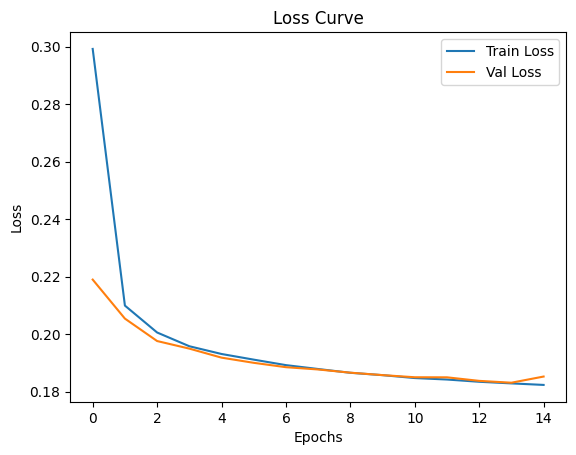

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

##Step 7: Evaluate & Visualize Results

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


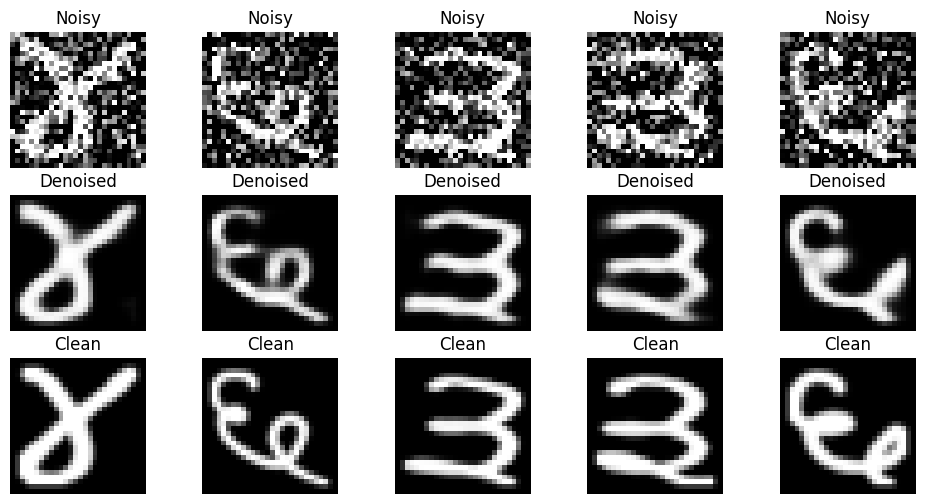

In [ ]:
denoised = autoencoder.predict(x_val_noisy)

def plot_results(noisy, denoised, clean, n=5):
    plt.figure(figsize=(12,6))

    for i in range(n):
        # Noisy
        plt.subplot(3, n, i+1)
        plt.imshow(noisy[i].reshape(28,28), cmap='gray')
        plt.axis('off')
        plt.title("Noisy")

        # Denoised
        plt.subplot(3, n, i+1+n)
        plt.imshow(denoised[i].reshape(28,28), cmap='gray')
        plt.axis('off')
        plt.title("Denoised")

        # Clean
        plt.subplot(3, n, i+1+2*n)
        plt.imshow(clean[i].reshape(28,28), cmap='gray')
        plt.axis('off')
        plt.title("Clean")

    plt.show()

plot_results(x_val_noisy, denoised, x_val)

##Experiment and Fine - Tune the Model:

###When different noise levels are applied, the performance of the denoising autoencoder changes noticeably. At a noise factor of 0.3, images are only slightly affected, so the model reconstructs them clearly and close to the original. At a noise level of 0.5, the images are more distorted, resulting in somewhat blurry outputs with some loss of fine details. At a high noise level of 0.7, the images become heavily corrupted, making it difficult for the model to learn useful features, which leads to very blurry and less accurate results. In general, higher noise levels reduce reconstruction quality and model performance.

###The loss curves show how the model behaves with different numbers of training epochs. At 10 epochs, both training and validation loss are still decreasing, which indicates that the model has not fully learned the patterns yet. At 15 epochs, both losses become stable and remain close to each other, showing good learning and good generalization. At 20 epochs, training loss continues to decrease, but validation loss starts to fluctuate and increase slightly, which indicates overfitting, meaning the model is memorizing training data instead of learning general patterns. Therefore, 15 epochs provide the best balance between learning and performance on unseen data.

###The number of filters in a convolutional autoencoder is controlled in the Conv2D layers. Increasing the number of filters (for example from 32 to 64 or 128) allows the model to learn more complex features and improves reconstruction quality, but it also increases computation time and resource usage. Reducing the number of filters (for example from 64 to 32 or 16) makes the model faster and more efficient, but may reduce its ability to capture important details, resulting in lower-quality outputs. A balanced configuration, such as 32 and 64 filters, usually provides a good trade-off between performance and efficiency.